In [1]:
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
x = torch.linspace(-2, 2, 50).unsqueeze(1)

In [4]:
x

tensor([-2.0000, -1.9664, -1.9328, -1.8992, -1.8655, -1.8319, -1.7983, -1.7647,
        -1.7311, -1.6975, -1.6639, -1.6303, -1.5966, -1.5630, -1.5294, -1.4958,
        -1.4622, -1.4286, -1.3950, -1.3613, -1.3277, -1.2941, -1.2605, -1.2269,
        -1.1933, -1.1597, -1.1261, -1.0924, -1.0588, -1.0252, -0.9916, -0.9580,
        -0.9244, -0.8908, -0.8571, -0.8235, -0.7899, -0.7563, -0.7227, -0.6891,
        -0.6555, -0.6218, -0.5882, -0.5546, -0.5210, -0.4874, -0.4538, -0.4202,
        -0.3866, -0.3529, -0.3193, -0.2857, -0.2521, -0.2185, -0.1849, -0.1513,
        -0.1176, -0.0840, -0.0504, -0.0168,  0.0168,  0.0504,  0.0840,  0.1176,
         0.1513,  0.1849,  0.2185,  0.2521,  0.2857,  0.3193,  0.3529,  0.3866,
         0.4202,  0.4538,  0.4874,  0.5210,  0.5546,  0.5882,  0.6218,  0.6555,
         0.6891,  0.7227,  0.7563,  0.7899,  0.8235,  0.8571,  0.8908,  0.9244,
         0.9580,  0.9916,  1.0252,  1.0588,  1.0924,  1.1261,  1.1597,  1.1933,
         1.2269,  1.2605,  1.2941,  1.32

In [20]:
x

tensor([[-2.0000],
        [-1.9184],
        [-1.8367],
        [-1.7551],
        [-1.6735],
        [-1.5918],
        [-1.5102],
        [-1.4286],
        [-1.3469],
        [-1.2653],
        [-1.1837],
        [-1.1020],
        [-1.0204],
        [-0.9388],
        [-0.8571],
        [-0.7755],
        [-0.6939],
        [-0.6122],
        [-0.5306],
        [-0.4490],
        [-0.3673],
        [-0.2857],
        [-0.2041],
        [-0.1224],
        [-0.0408],
        [ 0.0408],
        [ 0.1224],
        [ 0.2041],
        [ 0.2857],
        [ 0.3673],
        [ 0.4490],
        [ 0.5306],
        [ 0.6122],
        [ 0.6939],
        [ 0.7755],
        [ 0.8571],
        [ 0.9388],
        [ 1.0204],
        [ 1.1020],
        [ 1.1837],
        [ 1.2653],
        [ 1.3469],
        [ 1.4286],
        [ 1.5102],
        [ 1.5918],
        [ 1.6735],
        [ 1.7551],
        [ 1.8367],
        [ 1.9184],
        [ 2.0000]])

In [25]:
noise = 0.6 * torch.randn_like(x)
y = 3 * x + 2 + noise

In [28]:
import matplotlib.pyplot as plt

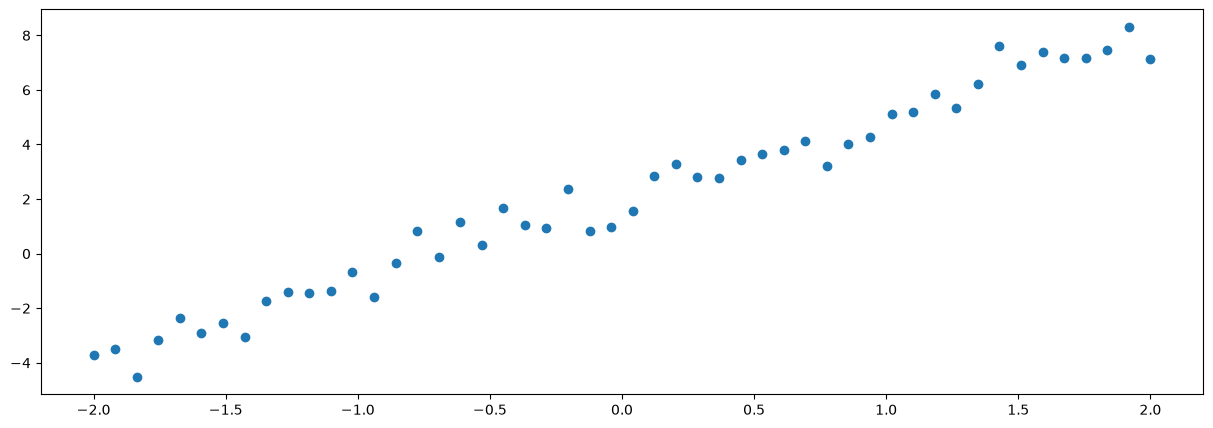

In [29]:
plt.figure(figsize=(15, 5))
plt.scatter(x, y)

In [30]:
import torch.nn as nn

In [31]:
model = nn.Linear(1, 1)

In [77]:
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
epochs = 100
losses = []
for epoch in range(epochs):
    y_pred = model(x)
    loss = loss_function(y, y_pred)
    optimizer.zero_grad()
    loss.backward()
    losses.append(loss.item())
    optimizer.step()   
    if epoch % 100 == 0:
        print(f'Epoch {epoch}/{epochs}, Loss: {loss.item()}')

Epoch 0/100, Loss: 0.313406765460968


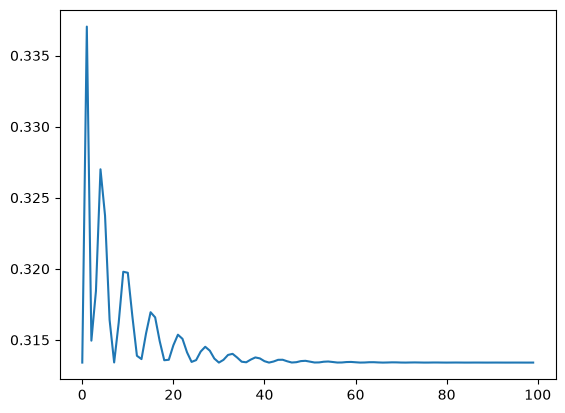

In [78]:
plt.plot(losses)

In [61]:
with torch.inference_mode():
    pred = model(x)

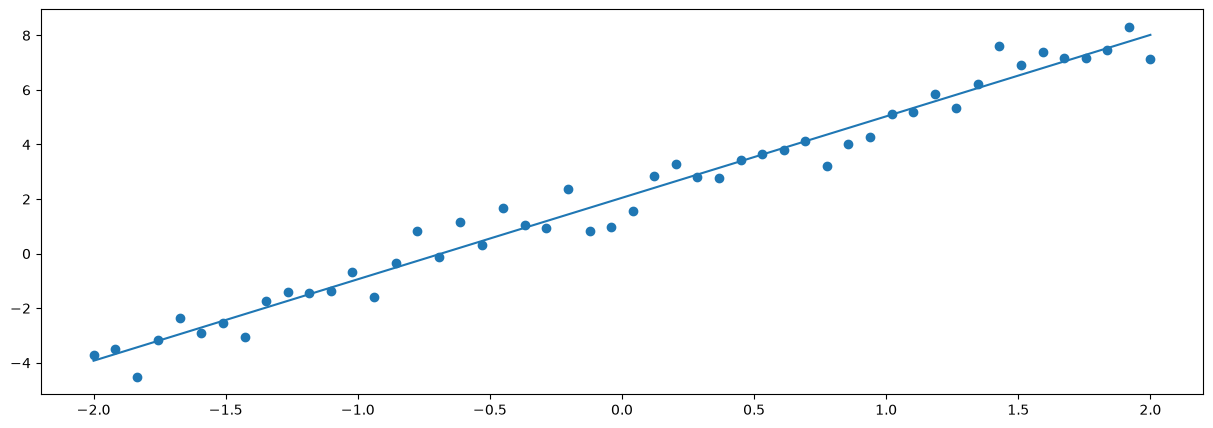

In [62]:
plt.figure(figsize=(15, 5))
plt.scatter(x, y)
plt.plot(x,pred)

In [63]:
from torcheval.metrics import R2Score

In [64]:
r2_score = R2Score()
r2_score.update(y, pred)
score = r2_score.compute()

In [65]:
print(score)

tensor(0.9747)
